# Base de données

In [ ]:
#PARTIE VALOU

In [ ]:
#initialisation 

## vérifier à la fin si on utilise bien tout ces import ##

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
#import contextily as ctx      #marchait pas
import seaborn as sns          #ajout par rapport au main

df = pd.read_csv("../output/df_modele_musees.csv")
df.head()

,id_patrimostat,id_museofile,dateappellation,ferme,anneefermeture,ville,codeInseeCommune,annee,payant,gratuit,...,annee_creation,latitude,longitude,total_frequentation,age_musee,age_musee_missing,total_t_1,croissance_total,has_excel,est_idf
0,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2014,1865.0,2685.0,...,1960.0,48.410166,7.451102,4550.0,54.0,0,NaN,NaN,1,0
1,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2015,1874.0,1934.0,...,1960.0,48.410166,7.451102,3808.0,55.0,0,4550.0,-0.163077,1,0
2,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2016,1705.0,1409.0,...,1960.0,48.410166,7.451102,3114.0,56.0,0,3808.0,-0.182248,1,0
3,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2017,1163.0,1281.0,...,1960.0,48.410166,7.451102,2444.0,57.0,0,3114.0,-0.215157,1,0
4,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2018,1249.0,2341.0,...,1960.0,48.410166,7.451102,3590.0,58.0,0,2444.0,0.468903,1,0


## Statistiques descriptives

In [3]:
#Aperçu du dataframe : une ligne = un musée pour une année
#df.info()

#Stat desc sur le total de fréquentation
df["total"].describe()

count    1.124800e+04
mean     5.018695e+04
std      3.477633e+05
min      0.000000e+00
25%      2.029500e+03
50%      8.481000e+03
75%      2.650125e+04
max      1.010596e+07
Name: total, dtype: float64

Ce résumé nous donne une première idée des caractéristiques de notre dataset, afin de faire des graphiques plus pertinents par la suite. Par exemple, le fait que l'écart-type soit très grand signifie qu'il y a une forte hétérogénéité entre les musées. Cela se voit de plus car la médiane est de 8 481 visiteurs et la moyenne de 50 186 visiteurs : quelques musées connus concentrent la majorité des visites.

## Représentation géographique

In [ ]:
#PARTIE VALOU

## Analyse globale de la fréquentation

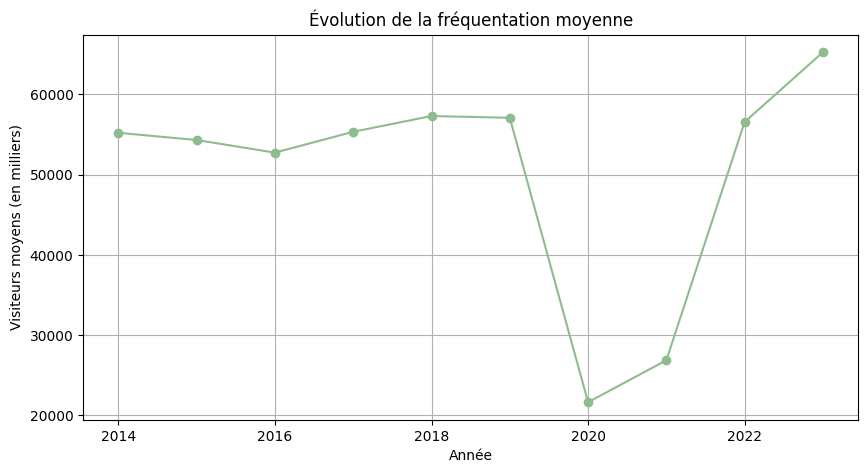

In [ ]:
# ÉVOLUTION DE LA FRÉQUENTATION MOYENNE
df_year = df.groupby("annee")["total"].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(df_year["annee"], df_year["total"], marker="o", color ="darkseagreen")
plt.title("Évolution de la fréquentation moyenne")
plt.xlabel("Année")
plt.ylabel("Visiteurs moyens")
plt.grid(True)
plt.show()

Alors que la fréquentation moyenne pré-COVID stagnait autour de 55 000 de visiteurs par an, la chute due au COVID semble avoir lancé une nouvelle dynamique. On observe d'abord un retour à la normale en 2022, puis une hausse de la fréquentation moyenne en 2023. *Dans notre modélisation, nous tenterons donc de comprendre si cette hausse est exceptionnelle ou s'apparente à une nouvelle tendance de long-terme.*

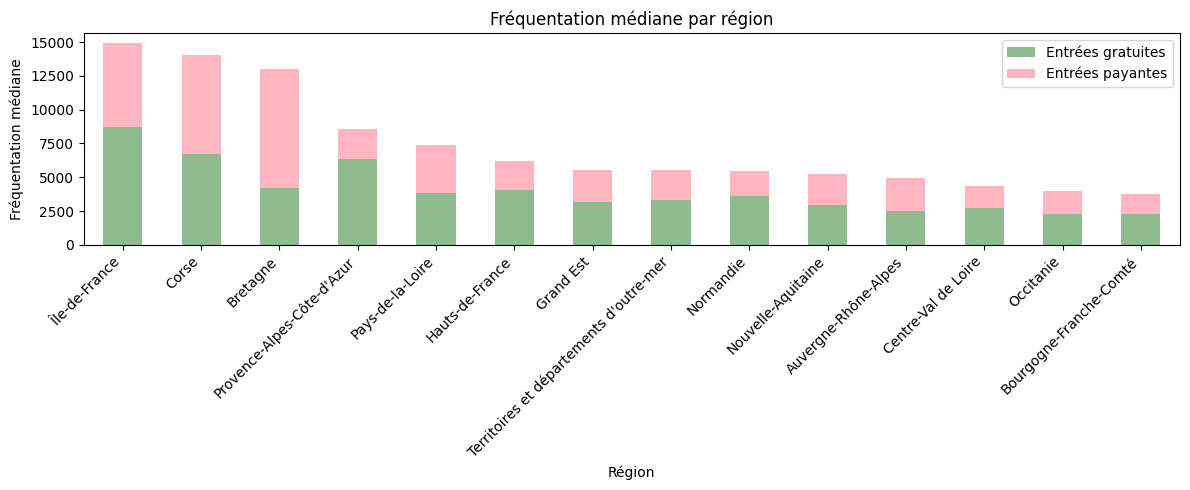

In [ ]:
# FRÉQUENTATION MÉDIANE PAR RÉGION : ENTRÉES PAYANTES ET GRATUITES

df_med_sep = (
    df.groupby("region")[["gratuit", "payant"]]
      .median()
      .assign(total_med=lambda x: x["gratuit"] + x["payant"])   # création d'une colonne total pour le tri
      .sort_values("total_med", ascending=False)
)

df_med_sep[["gratuit", "payant"]].plot(  # affichage des colonnes gratuit et médian (pas total)
    kind="bar",
    stacked=True,   # barres empilées
    figsize=(12,5),
    color=["darkseagreen", "lightpink"]
)

plt.title("Fréquentation médiane par région")
plt.ylabel("Fréquentation médiane")
plt.xlabel("Région")
plt.xticks(rotation=45, ha="right")
plt.legend(["Entrées gratuites", "Entrées payantes"])
plt.tight_layout()
plt.show()

Dans un premier temps, nous avons tenté de regarder la fréquentation moyenne par région. Or, les valeurs atteintes par les musées d'Île-de-France n'étaient pas propices à la comparaison régionale. Nous nous sommes donc intéressées à la médiane qui permet une meilleure interprétation des tendances en limitant l'importance des valeurs aberrantes.

On observe que l'Île-de-France, la Corse et la Bretagne possèdent une fréquentation médiane similaire. Néanmoins, la structure de cette fréquentation diffère : les entrées gratuites représentent 57.9% des entrées totales en Île-de-France, alors que la Bretagne est l'une des régions avec la plus faible proportion d'entrées gratuites avec seulement 39.8%. Dans la majorité des régions, il apparaît que les entrées gratuites représentent plus de la moitié de la fréquentation médiane des musées.

In [ ]:
# TOP 10 DES MUSÉES LES PLUS VISITÉS HORS IDF

df_sans_idf = df[df["region"] != "Île-de-France"]

top_musees_fr = (
    df_sans_idf.groupby("nom_officiel")
      .agg(                                       # sélectionner plusieurs colonnes pour le tableau
          total_visites=("total", "sum"),
          region=("region", "first"),                           
          domaine=("domaine_thematique", "first")
      )
      .sort_values("total_visites", ascending=False)
      .head(10)
      .reset_index()
)

top_musees_fr.columns = [
    "Nom du musée",
    "Total des visites",
    "Région",
    "Domaine thématique"
]

top_musees_fr

,Nom du musée,Total des visites,Région,Domaine thématique
0,musée des beaux-arts,22617440.0,Grand Est,Beaux-arts
1,muséum d'histoire naturelle,11473692.0,Bourgogne-Franche-Comté,Sciences de la nature;Technique et industrie;E...
2,musée des Confluences,5728990.0,Auvergne-Rhône-Alpes,Art moderne et contemporain;Beaux-arts;Photogr...
3,musée des civilisations de l'Europe et de la M...,4675648.0,Provence-Alpes-Côte-d'Azur,Ethnologie;Histoire
4,château musées,2741113.0,Centre-Val de Loire,Archéologie;Arts décoratifs;Beaux-arts;Ethnolo...
5,musée archéologique,2582738.0,Grand Est,Archéologie
6,musée du Débarquement,2541811.0,Normandie,Histoire
7,musée du château des ducs de Bretagne,2531139.0,Pays-de-la-Loire,Archéologie;Arts décoratifs;Art moderne et con...
8,Palais-musée des Archevêques de Narbonne,2417238.0,Occitanie,Archéologie;Arts décoratifs;Art moderne et con...
9,musée municipal,2369975.0,Nouvelle-Aquitaine,Archéologie;Histoire;Technique et industrie


Dans un premier temps, il est important de souligner que seuls les deux premiers musées de ce classement arrivent à concurrencer les musées d'Île-de-France pour se classer dans le top 10 des musées français. On remarque de plus une différence sur les domaines thématiques qui attirent les visiteurs entre l'Île-de-France et le reste des régions. En effet, l'archéologie ne ressort pas beaucoup en Île-de-France, plutôt axée sur l'art, alors qu'elle est prépondérante en région.

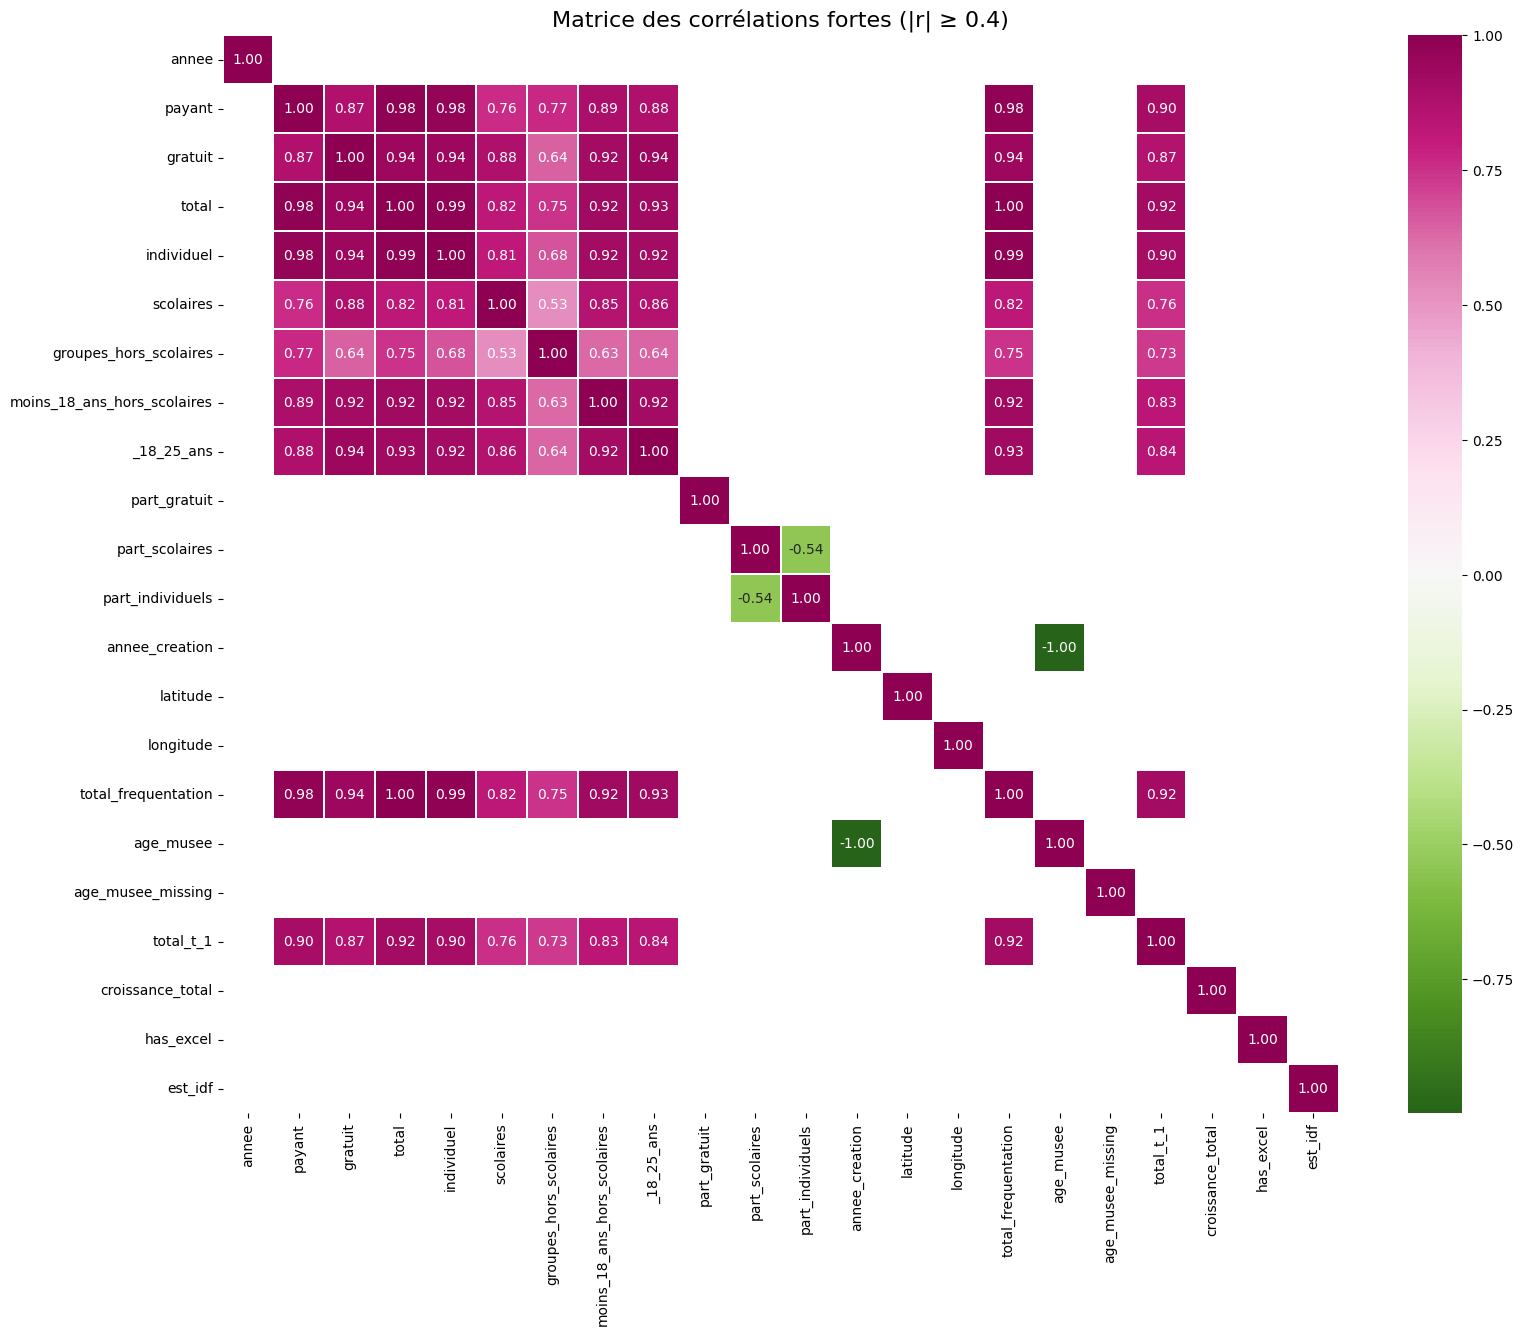

In [24]:
#MATRICE DES CORRÉLATIONS

# Sélectionner uniquement les colonnes numériques
num_cols = df.select_dtypes(include='number') 

# Sélectionner que les corrélation fortes (au moins 0.4 ou au plus -0.4)
corr = num_cols.corr()
strong_corr = corr.where(corr.abs() >= 0.4)

plt.figure(figsize=(18, 14))
sns.heatmap(
    strong_corr,
    cmap="PiYG_r",
    annot=True,       # affiche les valeurs de chaque case    
    center=0,  
    linewidths=0.3,
    fmt=".2f"         # précision au centième près dans chaque case
)

plt.title("Matrice des corrélations fortes (|r| ≥ 0.4)", fontsize=16)
plt.show()

Le bloc principal, en haut à gauche de la matrice, montre des corrélations très fortes entre les variables de fréquentation. Cela confirme un phénomène de taille : les musées les plus fréquentés attirent toutes les catégories de visiteurs. Néanmoins, cela implique une multicolinéarité élevée, qu'il faudra faire prendre en compte dans notre modèle prédictif. 

La faible corrélation avec la lattitude et la longitude semble indiquer que la localisation géographique n'explique pas le volume des visiteurs. 

La corrélation très forte entre total_t_1 et total_frequentation (r ≈ 0.92) indique que la fréquentation d’une année est fortement liée à celle de l’année précédente, ce qui nous conforte dans la possibilité et la pertinence d'un modèle prédisant l'évolution de la fréquentation.

## Analyse des publics

In [ ]:
#CRÉER LES CATÉGORIES 
#bcp de NaN et catégories diff, trier

In [27]:
#Stat desc sur les différentes parts
print(df[["part_gratuit","part_scolaires","part_individuels"]].describe())

       part_gratuit  part_scolaires  part_individuels
count   9835.000000     8533.000000       8475.000000
mean       0.546975        0.150406          0.746921
std        0.312579        0.152455          0.227458
min        0.000000        0.000000          0.000000
25%        0.290885        0.038792          0.651140
50%        0.533213        0.109170          0.797020
75%        0.813839        0.215014          0.895077
max        1.000000        1.896552          6.773839


En moyenne, les entrées gratuites représentent 54.69% des entrées totales d'un musée. *faire un commentaire sur l'accès à la culture ?*
En moyenne, les groupes scolaires représentent 15.04% des entrées totales d'un musée. L'écart-type étant de faible (0.15), on comprend que cette moyenne ne varie que très peu entre les musées.
*le total n'est pas égal à 1, problème ?*